<a href="https://colab.research.google.com/github/seungmei/QNS/blob/main/PTCDA%2BFe_huckel_theory_simulation_260521.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PTCDA + Fe Huckel Model

Toy model: why does the PTCDA-derived HOMO dI/dV peak shift to lower bias when Fe atoms bind near the end carbonyl groups?


- Fe-O hybridization through `beta_fe_o`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.rcParams.update({
    'figure.dpi':          110,
    'savefig.dpi':         300,
    'font.family':         'sans-serif',
    'font.size':           12,
    'axes.titlesize':      13,
    'axes.titleweight':    'bold',
    'axes.labelsize':      12,
    'axes.linewidth':      1.3,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.top':           True,
    'ytick.right':         True,
    'xtick.major.size':    5,
    'ytick.major.size':    5,
    'xtick.minor.size':    3,
    'ytick.minor.size':    3,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.frameon':      True,
    'legend.framealpha':   1.0,
    'legend.fontsize':     10,
    'lines.linewidth':     2.0,
    'lines.markersize':    6,
})


def origin_style(ax, minor=True):
    ax.tick_params(which='both', direction='in', top=True, right=True)
    if minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    for sp in ax.spines.values():
        sp.set_linewidth(1.3)
    return ax


np.set_printoptions(precision=4, suppress=True)

## 1. Local Density of State

$$H_{ii}=\alpha_i, \qquad H_{ij}=\beta_{ij}\quad \text{if bonded.}$$

$$H C = C E, \qquad dI/dV(V) \propto \sum_n w_n L(V-V_n;\gamma).$$

In [2]:
def make_hamiltonian(n_sites, onsite, bonds):
    H = np.zeros((n_sites, n_sites))
    H[np.arange(n_sites), np.arange(n_sites)] = onsite
    for i, j, beta in bonds:
        H[i, j] = H[j, i] = beta
    return H


def solve_huckel(H):
    if not np.allclose(H, H.T, atol=1e-12):
        raise ValueError('Hamiltonian must be symmetric')
    return np.linalg.eigh(H)


def lorentzian(x, center, gamma):
    return gamma / (np.pi * ((x - center)**2 + gamma**2))


def normalize_peak(y):
    return np.asarray(y) / (np.nanmax(np.abs(y)) + 1e-15)


def broadened_spectrum(centers, V_axis, gamma, weights=None):
    centers = np.asarray(centers)
    if weights is None:
        weights = np.ones_like(centers)
    peaks = lorentzian(V_axis[None, :], centers[:, None], gamma)
    return np.sum(np.asarray(weights)[:, None] * peaks, axis=0)

## 2. Benzene sanity check

Expected: $\{-2,-1,-1,+1,+1,+2\}\,|\beta|$ from $E_k = \alpha + 2\beta \cos(2\pi k/N)$.

benzene energies / |beta| : [-2.0, -1.0, -1.0, 1.0, 1.0, 2.0]
expected                  : [-2.0, -1.0, -1.0, 1.0, 1.0, 2.0]
max error                 : 4.44e-16


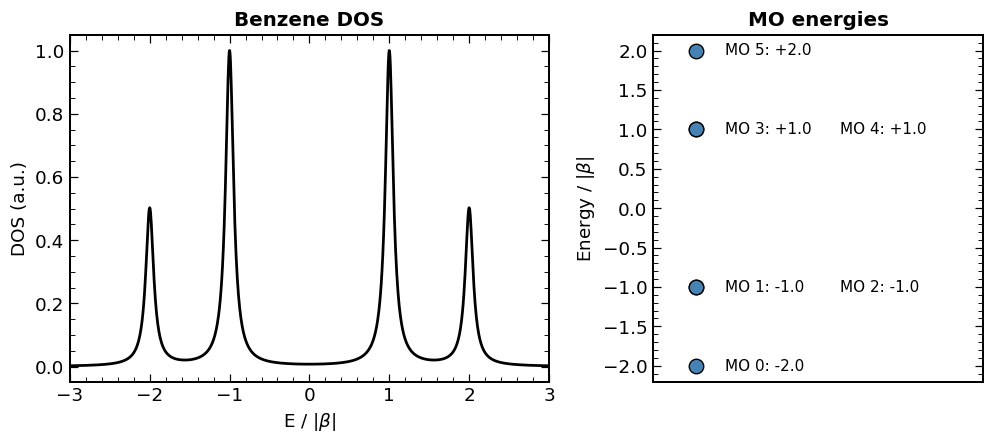

In [3]:
def build_benzene(alpha=0.0, beta=-1.0):
    onsite = [alpha] * 6
    bonds = [(i, (i + 1) % 6, beta) for i in range(6)]
    H = make_hamiltonian(6, onsite, bonds)
    E, C = solve_huckel(H)
    return H, E, C


H_benz, E_benz, _ = build_benzene()
expected = np.array([-2, -1, -1, 1, 1, 2], dtype=float)
err = np.max(np.abs(E_benz - expected))
assert err < 1e-10
print(f'benzene energies / |beta| : {np.round(E_benz, 3).tolist()}')
print(f'expected                  : {expected.tolist()}')
print(f'max error                 : {err:.2e}')

V_benz = np.linspace(-3, 3, 1200)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2),
                         gridspec_kw={'width_ratios': [1.45, 1.0]})

axes[0].plot(V_benz,
             normalize_peak(broadened_spectrum(E_benz, V_benz, gamma=0.06)),
             color='black', lw=1.8)
axes[0].set_xlabel(r'E / $|\beta|$')
axes[0].set_ylabel('DOS (a.u.)')
axes[0].set_title('Benzene DOS')
axes[0].set_xlim(-3, 3)
origin_style(axes[0])

axes[1].scatter(np.zeros_like(E_benz), E_benz, s=90, color='steelblue',
                edgecolor='black', linewidth=0.9, zorder=3)

# 같은 에너지 레벨이 겹칠 때 x 좌표를 0.4씩 오른쪽으로 밀어서 표시
seen = {}
for idx, e in enumerate(E_benz):
    key = round(e, 3)
    x_pos = 0.10 + seen.get(key, 0) * 0.4
    axes[1].text(x_pos, e, f'MO {idx}: {e:+.1f}', va='center', fontsize=10)
    seen[key] = seen.get(key, 0) + 1

axes[1].set_xlim(-0.15, 1.0)
axes[1].set_xticks([])
axes[1].set_ylabel(r'Energy / $|\beta|$')
axes[1].set_title('MO energies')
origin_style(axes[1], minor=False)
axes[1].tick_params(axis='x', which='both', bottom=False, top=False)
plt.tight_layout()
plt.show()

## 3. PTCDA + Fe Hückel matrix

28 π sites = 20 perylene C + 4 carbonyl C + 4 carbonyl O. Bridge O is sp3-like and is **not** in the π basis. 28 π electrons (1 e⁻ per site), so HOMO index = 13, LUMO index = 14.

Each Fe is one effective d-like orbital coupled to a single carbonyl O via $\beta_\mathrm{Fe\text{-}O}$, contributing 1 e⁻. Fe-Fe direct coupling is ignored.

In [4]:
# Effective Hückel parameters (eV). beta_CC = -2.5 eV; |alpha| slightly > |beta_CC|.
PARAMS = {
    'alpha_c':          -3.00,
    'alpha_o_carbonyl': -4.00,
    'alpha_fe':         -2.20,
    'beta_cc':          -2.50,
    'beta_co_double':   -2.30,
    'beta_fe_o':        -1.00,
    'gamma':             0.08,
}

A_CC   = 1.40   # C-C bond length (Å)
A_FE_O = 2.00   # Fe-O coordination distance (Å)

N_PTCDA_SITES     = 28
N_PTCDA_ELECTRONS = 28
N_FE_ELECTRONS    = 1
HOMO_INDEX        = N_PTCDA_ELECTRONS // 2 - 1   # 13
LUMO_INDEX        = HOMO_INDEX + 1               # 14
CARBONYL_O        = [24, 25, 26, 27]


def params_with(update=None):
    p = dict(PARAMS)
    if update:
        p.update(update)
    return p


def build_ptcda_geometry(params=None):
    a  = A_CC
    sx = a * np.sqrt(3) / 2
    naph = np.array([
        [0.0, a/2], [0.0, -a/2],
        [sx, a], [2*sx, a/2], [2*sx, -a/2], [sx, -a],
        [-sx, a], [-2*sx, a/2], [-2*sx, -a/2], [-sx, -a],
    ])
    coords = np.vstack([
        naph + [0.0,  1.5*a], naph + [0.0, -1.5*a],
        [[ sx,  3.5*a], [-sx,  3.5*a], [ sx, -3.5*a], [-sx, -3.5*a]],
        [[ 2*sx, 4.0*a], [-2*sx, 4.0*a], [2*sx, -4.0*a], [-2*sx, -4.0*a]],
    ])
    labels = ['C']*20 + ['Can']*4 + ['Oco']*4

    p = params_with(params)
    b_cc, b_co_d = p['beta_cc'], p['beta_co_double']
    naph_internal = [(0,1),(0,2),(0,6),(1,5),(1,9),
                     (2,3),(3,4),(4,5),(6,7),(7,8),(8,9)]
    bonds = []
    for i, j in naph_internal:
        bonds += [(i, j, b_cc), (10+i, 10+j, b_cc)]
    bonds += [(5, 12, b_cc), (9, 16, b_cc),
              (2, 20, b_cc), (6, 21, b_cc), (15, 22, b_cc), (19, 23, b_cc),
              (20, 24, b_co_d), (21, 25, b_co_d),
              (22, 26, b_co_d), (23, 27, b_co_d)]
    coords = coords[:, [1, 0]]   # +x = long axis, +y = short axis
    return coords, labels, bonds


def fe_binding_sites(params=None):
    coords, _, _ = build_ptcda_geometry(params)
    sites = []
    for ox_idx in CARBONYL_O:
        ox = coords[ox_idx]
        outward = ox / (np.linalg.norm(ox) + 1e-12)
        sites.append((ox + A_FE_O * outward, ox_idx))
    return sites


# Bridge O: visualization only, NOT in the 28-site basis.
BRIDGE_O_TO_CAN = {0: (20, 21), 1: (22, 23)}


def bridge_o_positions():
    return np.array([[ 4 * A_CC, 0.0],
                     [-4 * A_CC, 0.0]])


def _draw_bridge_o(ax, params=None, z=None, scale=1.0, alpha=0.55,
                   label_atoms=False):
    coords, _, _ = build_ptcda_geometry(params)
    br = bridge_o_positions()
    color_atom, color_bond = '#d99', '0.55'

    for br_idx, (ca_a, ca_b) in BRIDGE_O_TO_CAN.items():
        bx, by = br[br_idx]
        for ca in (ca_a, ca_b):
            cx, cy = coords[ca]
            if z is None:
                ax.plot([cx, bx], [cy, by], color=color_bond,
                        lw=1.0, ls='--', alpha=alpha, zorder=0)
            else:
                ax.plot([cx, bx], [cy, by], [z, z], color=color_bond,
                        lw=1.0, ls='--', alpha=alpha, zorder=0)

    if z is None:
        ax.scatter(br[:, 0], br[:, 1], s=70 * scale, c=color_atom,
                   marker='o', edgecolor='gray', linewidth=0.8,
                   alpha=alpha, zorder=2)
        if label_atoms:
            for x, y in br:
                ax.annotate('O*  (bridge,\nnot in basis)',
                            xy=(x, y), xytext=(8, 0),
                            textcoords='offset points',
                            fontsize=8, color='gray', alpha=0.85,
                            va='center')
    else:
        ax.scatter(br[:, 0], br[:, 1], [z, z], s=40 * scale, c=color_atom,
                   edgecolor='gray', linewidth=0.6, alpha=alpha,
                   depthshade=False)
    return br


def build_ptcda_fe_hamiltonian(n_fe=0, params=None):
    if not 0 <= n_fe <= 4:
        raise ValueError('n_fe must be 0..4')
    p = params_with(params)
    coords, labels, bonds = build_ptcda_geometry(params)
    n_p = len(coords)
    fe_sites = fe_binding_sites(params)[:n_fe]

    on_map = {'C': p['alpha_c'], 'Can': p['alpha_c'],
              'Oco': p['alpha_o_carbonyl']}
    onsite = np.array([on_map[t] for t in labels]
                      + [p['alpha_fe']] * n_fe)

    all_bonds = list(bonds)
    fe_coords = []
    for k, (fe_xy, ox_idx) in enumerate(fe_sites):
        all_bonds.append((ox_idx, n_p + k, p['beta_fe_o']))
        fe_coords.append(fe_xy)

    H = make_hamiltonian(n_p + n_fe, onsite, all_bonds)
    all_coords = (np.vstack([coords, np.array(fe_coords)])
                  if fe_coords else coords.copy())
    return H, all_coords, labels + ['Fe'] * n_fe


def solve_ptcda_fe(n_fe=0, params=None):
    H, coords, labels = build_ptcda_fe_hamiltonian(n_fe=n_fe, params=params)
    E, C = solve_huckel(H)
    return {'H': H, 'coords': coords, 'labels': labels,
            'energies': E, 'orbitals': C, 'n_fe': n_fe,
            'params': params_with(params)}


def combined_filling(n_fe):
    n_tot  = N_PTCDA_ELECTRONS + n_fe * N_FE_ELECTRONS
    n_full = n_tot // 2
    homo   = n_full - 1 if n_tot % 2 == 0 else n_full
    return {'n_tot_e': n_tot, 'homo': homo, 'lumo': homo + 1,
            'open_shell': bool(n_tot % 2)}


def model_fermi_reference(params=None):
    s = solve_ptcda_fe(0, params=params)
    return 0.5 * (s['energies'][HOMO_INDEX] + s['energies'][LUMO_INDEX])


def energy_to_bias(E, params=None):
    return np.asarray(E) - model_fermi_reference(params)


sol0 = solve_ptcda_fe(0)
E_HOMO = sol0['energies'][HOMO_INDEX]
E_LUMO = sol0['energies'][LUMO_INDEX]
gap    = E_HOMO - E_LUMO

print(f"PTCDA sites: {len(sol0['labels'])}  "
      f"({dict((x, sol0['labels'].count(x)) for x in sorted(set(sol0['labels'])))})")
print(f"pi electrons: {N_PTCDA_ELECTRONS} (PTCDA) + {N_FE_ELECTRONS} per Fe")
print(f"HOMO / LUMO index: {HOMO_INDEX} / {LUMO_INDEX}")
print()
print(f"E_HOMO          = {E_HOMO:+.4f} eV")
print(f"E_LUMO          = {E_LUMO:+.4f} eV")
print(f"HOMO - LUMO gap = {gap:+.4f} eV   (|gap| = {abs(gap):.4f} eV)")
print(f"E_HOMO (vs E_F) = {energy_to_bias(E_HOMO):+.4f} eV")
print(f"E_LUMO (vs E_F) = {energy_to_bias(E_LUMO):+.4f} eV")
print()
print("filling table (total e- = 28 + n_Fe)")
print("  n_Fe  total e-  HOMO  LUMO  open shell")
for n_fe in range(5):
    f = combined_filling(n_fe)
    print(f"  {n_fe:>4d}  {f['n_tot_e']:>8d}  {f['homo']:>4d}  "
          f"{f['lumo']:>4d}  {str(f['open_shell']):>10s}")

PTCDA sites: 28  ({'C': 20, 'Can': 4, 'Oco': 4})
pi electrons: 28 (PTCDA) + 1 per Fe
HOMO / LUMO index: 13 / 14

E_HOMO          = -3.9124 eV
E_LUMO          = -2.7393 eV
HOMO - LUMO gap = -1.1731 eV   (|gap| = 1.1731 eV)
E_HOMO (vs E_F) = -0.5865 eV
E_LUMO (vs E_F) = +0.5865 eV

filling table (total e- = 28 + n_Fe)
  n_Fe  total e-  HOMO  LUMO  open shell
     0        28    13    14       False
     1        29    14    15        True
     2        30    14    15       False
     3        31    15    16        True
     4        32    15    16       False


### Atom-to-index map

PTCDA atoms occupy indices 0..27. Fe atoms get indices $28, 29, \ldots, 27 + n_\mathrm{Fe}$ in the binding order

$$\text{Fe}_0 \to \text{O}_{24},\quad \text{Fe}_1 \to \text{O}_{25},\quad \text{Fe}_2 \to \text{O}_{26},\quad \text{Fe}_3 \to \text{O}_{27}.$$

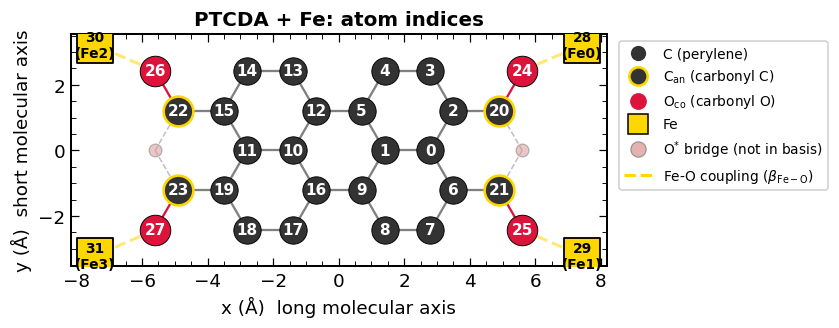

In [5]:
def plot_atom_index_map(params=None, figsize=(7.8, 7.2)):
    coords, labels, bonds = build_ptcda_geometry(params)
    fe_sites = fe_binding_sites(params)

    fig, ax = plt.subplots(figsize=figsize)

    for (i, j, _) in bonds:
        col = 'crimson' if 'Oco' in (labels[i], labels[j]) else '0.5'
        ax.plot([coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color=col, lw=1.5, zorder=1)

    _draw_bridge_o(ax)

    style = {'C':   dict(c='#333', s=320),
             'Can': dict(c='#333', s=380),
             'Oco': dict(c='crimson', s=400)}
    ec_of = {'C': 'black', 'Can': 'gold', 'Oco': 'black'}
    lw_of = {'C': 0.6,    'Can': 1.7,    'Oco': 0.6}

    for k, (R, lab) in enumerate(zip(coords, labels)):
        ax.scatter(R[0], R[1], edgecolor=ec_of[lab], linewidth=lw_of[lab],
                   zorder=3, **style[lab])
        ax.annotate(str(k), xy=(R[0], R[1]), ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white', zorder=4)

    for k, (fe_xy, ox_idx) in enumerate(fe_sites):
        ax.plot([coords[ox_idx, 0], fe_xy[0]],
                [coords[ox_idx, 1], fe_xy[1]],
                color='gold', lw=2.0, ls='--', alpha=0.55, zorder=2)
        ax.scatter(fe_xy[0], fe_xy[1], s=540, c='gold', marker='s',
                   edgecolor='black', linewidth=1.2, zorder=3)
        ax.annotate(f'{N_PTCDA_SITES + k}\n(Fe{k})',
                    xy=(fe_xy[0], fe_xy[1]), ha='center', va='center',
                    fontsize=9, fontweight='bold', color='black', zorder=4)

    from matplotlib.lines import Line2D
    leg = [
        Line2D([0], [0], marker='o', color='w', mfc='#333', ms=11,
               label='C (perylene)'),
        Line2D([0], [0], marker='o', color='w', mfc='#333', mec='gold',
               mew=1.7, ms=12, label=r'C$_\mathrm{an}$ (carbonyl C)'),
        Line2D([0], [0], marker='o', color='w', mfc='crimson', ms=12,
               label=r'O$_\mathrm{co}$ (carbonyl O)'),
        Line2D([0], [0], marker='s', color='w', mfc='gold', mec='black',
               mew=1.0, ms=13, label='Fe'),
        Line2D([0], [0], marker='o', color='w', mfc='#d99', mec='gray',
               mew=0.8, ms=10, alpha=0.75,
               label=r'O$^{*}$ bridge (not in basis)'),
        Line2D([0], [0], color='gold', lw=2.0, ls='--',
               label=r'Fe-O coupling ($\beta_\mathrm{Fe-O}$)'),
    ]
    ax.legend(handles=leg, loc='upper left', fontsize=9, framealpha=0.95,
              bbox_to_anchor=(1.01, 1.0))

    ax.set_aspect('equal')
    ax.set_xlabel('x (Å)  long molecular axis')
    ax.set_ylabel('y (Å)  short molecular axis')
    ax.set_title('PTCDA + Fe: atom indices')
    origin_style(ax, minor=False)
    plt.tight_layout()
    plt.show()


plot_atom_index_map()

## 4. Block-matrix view: $H = \begin{pmatrix} H_\mathrm{PTCDA} & V \\ V^{\top} & H_\mathrm{Fe} \end{pmatrix}$

$V_{ij}=\beta_\mathrm{Fe\text{-}O}$ on (carbonyl-O, Fe) pairs, 0 elsewhere. $H_\mathrm{Fe}=\mathrm{diag}(\alpha_\mathrm{Fe})$.

In [15]:
def split_blocks(H, n_ptcda=N_PTCDA_SITES):
    return (H[:n_ptcda, :n_ptcda],
            H[:n_ptcda, n_ptcda:],
            H[n_ptcda:, n_ptcda:])


def print_block_summary(n_fe, params=None):
    sol = solve_ptcda_fe(n_fe, params=params)
    H = sol['H']
    H_p, V, H_f = split_blocks(H)
    print(f'n_Fe = {n_fe}   H shape = {H.shape}   '
          f'blocks: H_PTCDA {H_p.shape}, V {V.shape}, H_Fe {H_f.shape}')
    print(np.array2string(H, precision=2, suppress_small=True,
                          max_line_width=240,
                          formatter={'float': '{:6.2f}'.format}))
    print()


def plot_block_matrix_grid(n_fe_list=(0, 1, 2, 3, 4), params=None):
    mats = [solve_ptcda_fe(n, params=params)['H'] for n in n_fe_list]
    vmax = max(abs(PARAMS['beta_cc']), abs(PARAMS['beta_co_double']), 1.0) + 0.5

    fig, axes = plt.subplots(1, len(n_fe_list),
                             figsize=(3.4 * len(n_fe_list), 4.0),
                             constrained_layout=True)
    for ax, n_fe, H in zip(axes, n_fe_list, mats):
        im = ax.imshow(H, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       interpolation='nearest')
        ax.axhline(N_PTCDA_SITES - 0.5, color='black', lw=1.0)
        ax.axvline(N_PTCDA_SITES - 0.5, color='black', lw=1.0)
        ax.set_title(f'n_Fe = {n_fe}  ({H.shape[0]}x{H.shape[0]})')
        ax.set_xticks([0, 10, 20, N_PTCDA_SITES])
        ax.set_yticks([0, 10, 20, N_PTCDA_SITES])
        ax.tick_params(labelsize=9)
    cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
    cb.set_label('H element (eV; diagonals clipped)')
    fig.suptitle('PTCDA + Fe coupling matrix heatmap', fontsize=14)
    plt.show()


_ATOM_STYLE = {
    'C':   dict(c='#222', s=55,  marker='o'),
    'Can': dict(c='#222', s=90,  marker='o', edgecolor='gold', linewidth=1.4),
    'Oco': dict(c='crimson', s=110, marker='o'),
    'Fe':  dict(c='gold',    s=230, marker='s', edgecolor='black', linewidth=1.2),
}


def plot_ptcda_fe_structure_grid(n_fe_list=(0, 1, 2, 3, 4), params=None):
    coords, labels, bonds = build_ptcda_geometry(params)
    fe_sites = fe_binding_sites(params)

    fig, axes = plt.subplots(1, len(n_fe_list),
                             figsize=(3.4 * len(n_fe_list), 4.0),
                             constrained_layout=True)

    br = bridge_o_positions()
    all_x = np.concatenate([coords[:, 0], [s[0][0] for s in fe_sites], br[:, 0]])
    all_y = np.concatenate([coords[:, 1], [s[0][1] for s in fe_sites], br[:, 1]])
    xlim = (all_x.min() - 0.9, all_x.max() + 0.9)
    ylim = (all_y.min() - 0.9, all_y.max() + 0.9)

    for ax, n_fe in zip(axes, n_fe_list):
        _draw_bridge_o(ax, params=params)
        for (i, j, _b) in bonds:
            col = 'crimson' if 'Oco' in (labels[i], labels[j]) else '0.4'
            ax.plot([coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color=col, lw=1.5, zorder=1)

        for kind in ('C', 'Can', 'Oco'):
            idx = [k for k, lab in enumerate(labels) if lab == kind]
            s = dict(_ATOM_STYLE[kind])
            ec = s.pop('edgecolor', 'black')
            lw = s.pop('linewidth', 0.5)
            ax.scatter(coords[idx, 0], coords[idx, 1],
                       edgecolor=ec, linewidth=lw, zorder=3, **s)

        for k in range(n_fe):
            fe_xy, ox_idx = fe_sites[k]
            ox = coords[ox_idx]
            ax.plot([ox[0], fe_xy[0]], [ox[1], fe_xy[1]],
                    color='gold', lw=2.0, ls='--', zorder=2)
            s = dict(_ATOM_STYLE['Fe'])
            ec = s.pop('edgecolor'); lw = s.pop('linewidth')
            ax.scatter([fe_xy[0]], [fe_xy[1]], edgecolor=ec, linewidth=lw,
                       zorder=4, **s)

        for ox_idx in CARBONYL_O:
            ox = coords[ox_idx]
            ax.annotate(str(ox_idx), xy=(ox[0], ox[1]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, color='crimson')

        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(1.1)
        ax.set_title(f'n_Fe = {n_fe}    H {N_PTCDA_SITES + n_fe}x{N_PTCDA_SITES + n_fe}',
                     fontsize=11)

    from matplotlib.lines import Line2D
    leg = [
        Line2D([0],[0], marker='o', color='w', mfc='#222', ms=8, label='C'),
        Line2D([0],[0], marker='o', color='w', mfc='#222', mec='gold',
               mew=1.4, ms=10, label='C (carbonyl)'),
        Line2D([0],[0], marker='o', color='w', mfc='crimson', ms=10,
               label='O (carbonyl)'),
        Line2D([0],[0], marker='s', color='w', mfc='gold', mec='black',
               mew=1.0, ms=11, label='Fe'),
        Line2D([0],[0], color='gold', lw=2.0, ls='--', label='Fe-O coupling'),
        Line2D([0],[0], marker='o', color='w', mfc='#d99', mec='gray',
               mew=0.8, ms=9, alpha=0.75, label='O* bridge (not in basis)'),
    ]
    fig.legend(handles=leg, loc='lower center', ncol=6, fontsize=9,
               framealpha=0.95, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle('PTCDA + Fe Hückel basis', fontsize=12)
    plt.show()

for n in (0, 1, 2, 3, 4):
    print_block_summary(n)

n_Fe = 0   H shape = (28, 28)   blocks: H_PTCDA (28, 28), V (28, 0), H_Fe (0, 0)
[[ -3.00  -2.50  -2.50   0.00   0.00   0.00  -2.50   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00]
 [ -2.50  -3.00   0.00   0.00   0.00  -2.50   0.00   0.00   0.00  -2.50   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00]
 [ -2.50   0.00  -3.00  -2.50   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00  -2.50   0.00   0.00   0.00   0.00   0.00   0.00   0.00]
 [  0.00   0.00  -2.50  -3.00  -2.50   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00]
 [  0.00   0.00   0.00  -2.50  -3.00  -2.50   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   

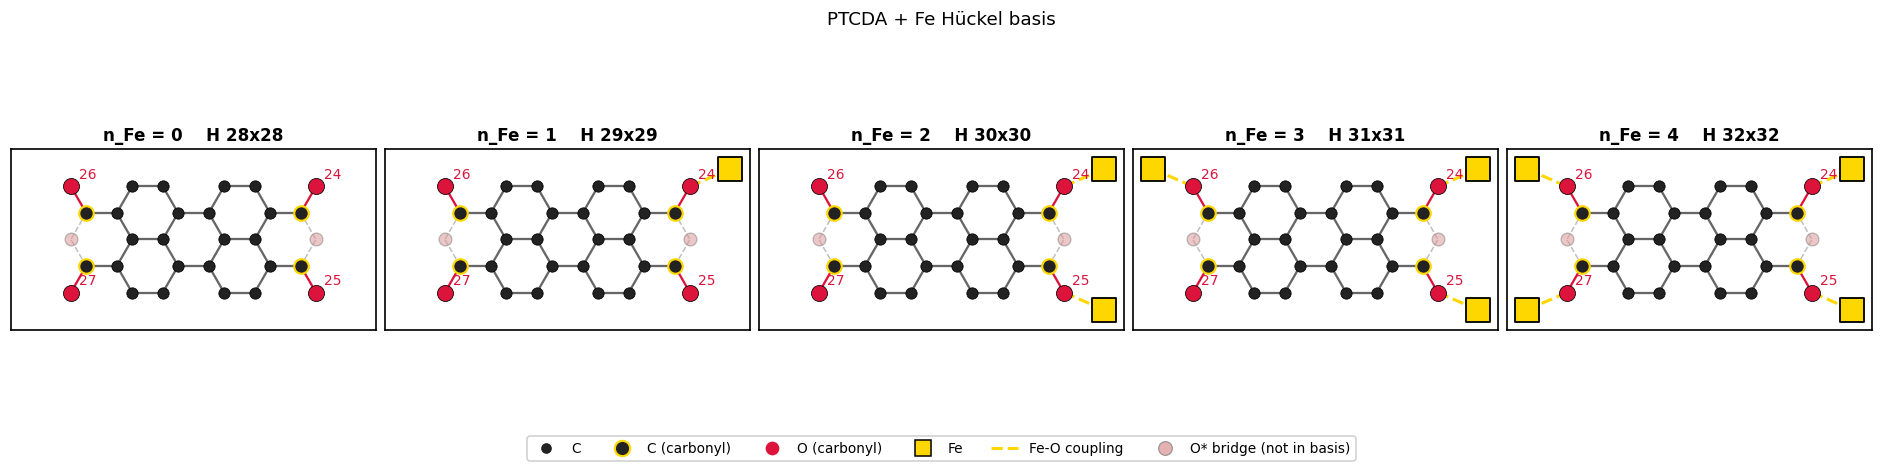

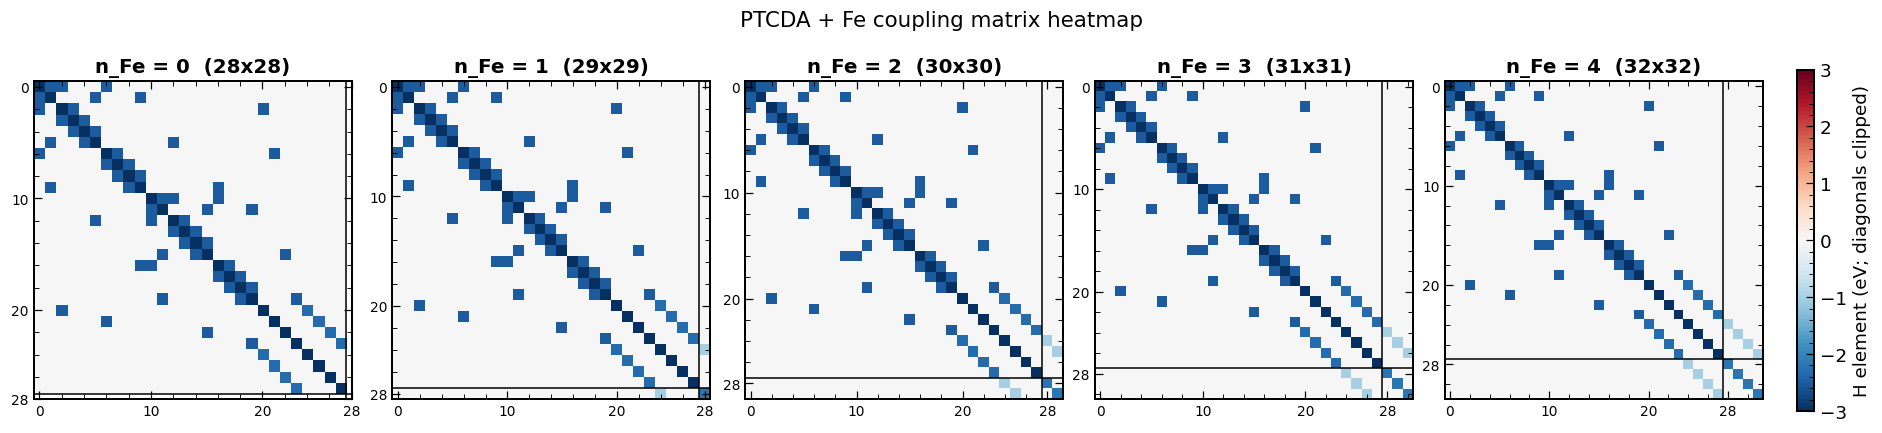

In [16]:
plot_ptcda_fe_structure_grid()
plot_block_matrix_grid()

## 5. HOMO-derived peak

Track the free-PTCDA HOMO by maximum overlap as Fe is added.

In [7]:
def reference_orbital(label='HOMO', params=None):
    sol0 = solve_ptcda_fe(0, params=params)
    idx = HOMO_INDEX if label.upper() == 'HOMO' else LUMO_INDEX
    return sol0['orbitals'][:, idx], sol0['energies'][idx], idx


def track_reference_orbital(label='HOMO', max_fe=4, params=None):
    """Track the free-PTCDA HOMO/LUMO across n_Fe by max overlap.
    Fe weight = sum of |c_i|^2 on Fe sites = direct measure of Fe-O hybridization."""
    ref_vec, ref_energy, _ = reference_orbital(label, params=params)
    n_ref = len(ref_vec)
    rows = []
    for n_fe in range(max_fe + 1):
        sol = solve_ptcda_fe(n_fe, params=params)
        overlap = np.abs(sol['orbitals'][:n_ref, :].T @ ref_vec)**2
        state = int(np.argmax(overlap))
        energy = float(sol['energies'][state])
        fe_weight = 0.0
        if sol['orbitals'].shape[0] > n_ref:
            fe_weight = float(np.sum(np.abs(sol['orbitals'][n_ref:, state])**2))
        rows.append({
            'n_fe': n_fe,
            'state': state,
            'energy': energy,
            'bias': float(energy_to_bias(energy, params=params)),
            'shift_V': float(energy_to_bias(energy, params=params)
                             - energy_to_bias(ref_energy, params=params)),
            'fe_weight': fe_weight,
        })
    return rows


def print_peak_table(label='HOMO', params=None):
    rows = track_reference_orbital(label, params=params)
    print(f'{label.upper()}-derived peak tracking')
    print('n_Fe  state   E-E_F(eV)   shift(eV)   E(eV)      Fe weight')
    for r in rows:
        print(f"{r['n_fe']:>4d}  {r['state']:>5d}  "
              f"{r['bias']:>+9.4f}  {r['shift_V']:>+9.4f}  "
              f"{r['energy']:>+10.4f}     {r['fe_weight']:>7.3f}")
    return rows


homo_rows = print_peak_table('HOMO')

HOMO-derived peak tracking
n_Fe  state   E-E_F(eV)   shift(eV)   E(eV)      Fe weight
   0     13    -0.5865    +0.0000     -3.9124       0.000
   1     13    -0.6293    -0.0428     -3.9552       0.021
   2     13    -0.6735    -0.0870     -3.9994       0.043
   3     13    -0.7136    -0.1270     -4.0394       0.060
   4     13    -0.7558    -0.1693     -4.0817       0.079


## 6. PTCDA-projected dI/dV peak shift

HOMO-derived peak positions
n_Fe   state   E-E_F (eV)    shift (eV)
   0      13       -0.5865     +0.0000
   1      13       -0.6293     -0.0428
   2      13       -0.6735     -0.0870
   3      13       -0.7136     -0.1270
   4      13       -0.7558     -0.1693


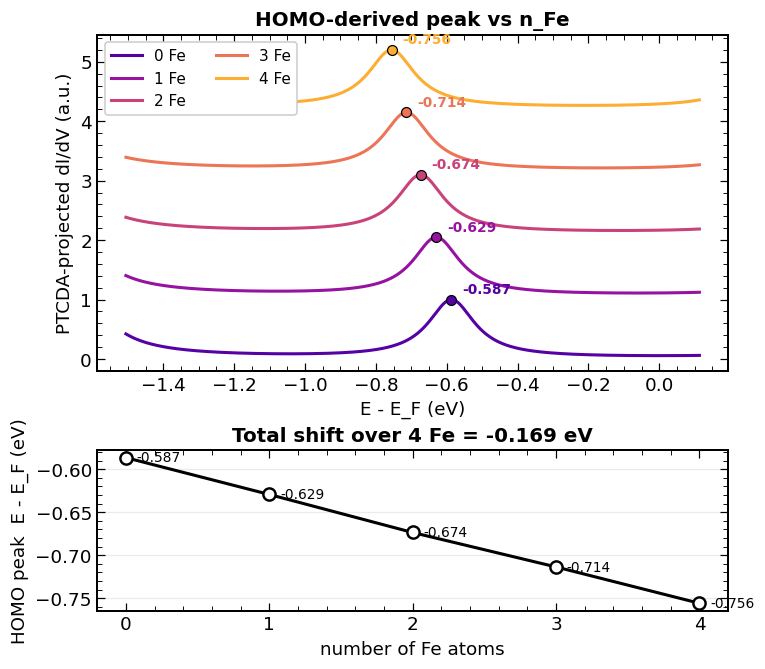

In [8]:
def ptcda_projection_weights(sol):
    return np.sum(np.abs(sol['orbitals'][:N_PTCDA_SITES, :])**2, axis=0)


def didv_spectrum(sol, V_axis, projection='ptcda'):
    centers = energy_to_bias(sol['energies'], params=sol['params'])
    weights = ptcda_projection_weights(sol) if projection == 'ptcda' else None
    return broadened_spectrum(centers, V_axis, sol['params']['gamma'],
                              weights=weights)


def plot_peak_shift_summary(label='HOMO', max_fe=4, params=None):
    rows = track_reference_orbital(label, max_fe=max_fe, params=params)
    V = np.linspace(min(r['bias'] for r in rows) - 0.75,
                    max(r['bias'] for r in rows) + 0.70, 2000)
    colors = plt.cm.plasma(np.linspace(0.15, 0.82, max_fe + 1))

    print(f'{label.upper()}-derived peak positions')
    print('n_Fe   state   E-E_F (eV)    shift (eV)')
    for r in rows:
        print(f"{r['n_fe']:>4d}   {r['state']:>5d}   "
              f"{r['bias']:>+11.4f}    {r['shift_V']:>+8.4f}")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.4, 6.8),
                                   gridspec_kw={'height_ratios': [2.1, 1],
                                                'hspace': 0.32})

    for n_fe, color in zip(range(max_fe + 1), colors):
        sol = solve_ptcda_fe(n_fe, params=params)
        y = normalize_peak(didv_spectrum(sol, V))
        offset = 1.05 * n_fe
        ax1.plot(V, y + offset, color=color, lw=2.0, label=f'{n_fe} Fe')
        peak_x = rows[n_fe]['bias']
        peak_y = np.interp(peak_x, V, y) + offset
        ax1.scatter([peak_x], [peak_y], s=42, color=color,
                    edgecolor='black', linewidth=0.8, zorder=5)
        ax1.annotate(f'{peak_x:+.3f}', xy=(peak_x, peak_y),
                     xytext=(7, 4), textcoords='offset points',
                     fontsize=9, color=color, fontweight='bold')

    ax1.set_xlabel('E - E_F (eV)')
    ax1.set_ylabel('PTCDA-projected dI/dV (a.u.)')
    ax1.set_title(f'{label.upper()}-derived peak vs n_Fe')
    ax1.legend(loc='upper left', ncol=2)
    origin_style(ax1)

    x = [r['n_fe'] for r in rows]
    y = [r['bias'] for r in rows]
    ax2.plot(x, y, 'o-', color='black', lw=2.0, ms=8, mfc='white', mew=1.6)
    for xi, yi in zip(x, y):
        ax2.annotate(f'{yi:+.3f}', xy=(xi, yi),
                     xytext=(7, 0), textcoords='offset points',
                     fontsize=9, va='center')
    ax2.set_xticks(x)
    ax2.set_xlabel('number of Fe atoms')
    ax2.set_ylabel(f'{label.upper()} peak  E - E_F (eV)')
    ax2.set_title(f'Total shift over 4 Fe = {rows[-1]["shift_V"]:+.3f} eV')
    ax2.grid(axis='y', alpha=0.25)
    origin_style(ax2)
    plt.show()
    return rows


peak_rows = plot_peak_shift_summary('HOMO')

## 7. Energy levels vs $|\beta_{CC}|$

Sweep $|\beta_{CC}|$ from 0; $\beta_{CO}$ and $\beta_\mathrm{Fe\text{-}O}$ scale proportionally so PARAMS ratios are preserved. At $\beta=0$ levels collapse to the on-site $\alpha$ values.

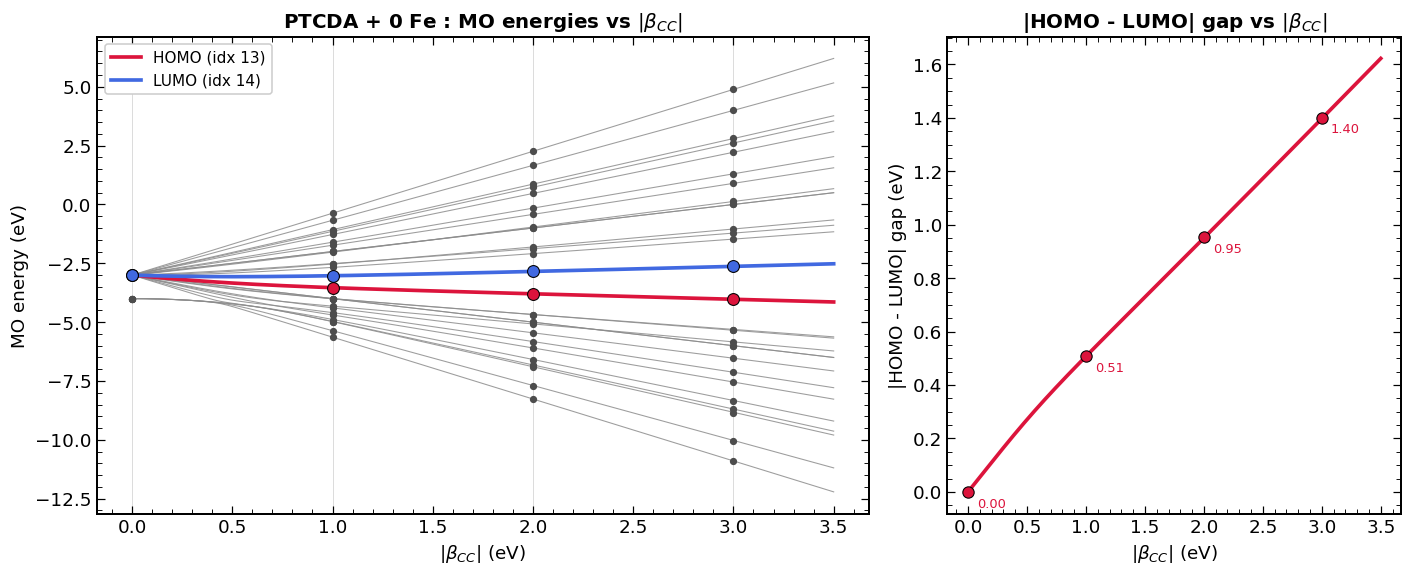

  |beta_CC| (eV)   HOMO (eV)    LUMO (eV)    |gap| (eV)
      0.0          -3.0000     -3.0000      0.0000
      1.0          -3.5355     -3.0270      0.5085
      2.0          -3.7964     -2.8439      0.9525
      3.0          -4.0295     -2.6288      1.4007


In [9]:
def beta_sweep_levels(beta_cc_values, n_fe=0, params=None):
    base = params_with(params)
    ratio_co = base['beta_co_double'] / base['beta_cc']
    ratio_fe = base['beta_fe_o']      / base['beta_cc']
    rows = []
    for b_cc in beta_cc_values:
        override = {'beta_cc':        b_cc,
                    'beta_co_double': b_cc * ratio_co,
                    'beta_fe_o':      b_cc * ratio_fe}
        rows.append(solve_ptcda_fe(n_fe, params=override)['energies'])
    return np.array(rows)


def plot_beta_sweep(n_fe=0, beta_max=3.5, n_points=200, params=None):
    beta_abs = np.linspace(0.0, beta_max, n_points)
    E = beta_sweep_levels(-beta_abs, n_fe=n_fe, params=params)

    fill = combined_filling(n_fe)
    homo_idx, lumo_idx = fill['homo'], fill['lumo']
    homo_track = E[:, homo_idx]
    lumo_track = E[:, lumo_idx]
    gap_abs    = np.abs(homo_track - lumo_track)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4),
                                   gridspec_kw={'width_ratios': [1.7, 1.0]})

    for n in range(E.shape[1]):
        ax1.plot(beta_abs, E[:, n], color='0.55', lw=0.7, alpha=0.85)
    ax1.plot(beta_abs, homo_track, color='crimson',   lw=2.4,
             label=f'HOMO (idx {homo_idx})')
    ax1.plot(beta_abs, lumo_track, color='royalblue', lw=2.4,
             label=f'LUMO (idx {lumo_idx})')

    marker_betas = np.arange(0, int(beta_max) + 1)
    for b in marker_betas:
        ax1.axvline(b, color='0.85', lw=0.6, zorder=0)
        idx = int(np.argmin(np.abs(beta_abs - b)))
        ax1.scatter([b] * E.shape[1], E[idx, :], s=14, color='0.3', zorder=2)
        ax1.scatter([b], [E[idx, homo_idx]],
                    s=60, color='crimson',   edgecolor='k', lw=0.7, zorder=4)
        ax1.scatter([b], [E[idx, lumo_idx]],
                    s=60, color='royalblue', edgecolor='k', lw=0.7, zorder=4)

    ax1.set_xlabel(r'$|\beta_{CC}|$ (eV)')
    ax1.set_ylabel('MO energy (eV)')
    ax1.set_title(rf'PTCDA + {n_fe} Fe : MO energies vs $|\beta_{{CC}}|$')
    ax1.legend(loc='best')
    origin_style(ax1)

    ax2.plot(beta_abs, gap_abs, color='crimson', lw=2.4)
    for b in marker_betas:
        idx = int(np.argmin(np.abs(beta_abs - b)))
        g = gap_abs[idx]
        ax2.scatter([b], [g], s=55, color='crimson', edgecolor='k',
                    lw=0.7, zorder=4)
        ax2.annotate(f'{g:.2f}', (b, g),
                     textcoords='offset points', xytext=(6, -10),
                     fontsize=8.5, color='crimson')
    ax2.set_xlabel(r'$|\beta_{CC}|$ (eV)')
    ax2.set_ylabel(r'|HOMO - LUMO| gap (eV)')
    ax2.set_title(r'|HOMO - LUMO| gap vs $|\beta_{CC}|$')
    origin_style(ax2)
    plt.tight_layout()
    plt.show()

    print('  |beta_CC| (eV)   HOMO (eV)    LUMO (eV)    |gap| (eV)')
    for b in marker_betas:
        idx = int(np.argmin(np.abs(beta_abs - b)))
        print(f'   {b:>6.1f}        {homo_track[idx]:>+9.4f}   {lumo_track[idx]:>+9.4f}    {gap_abs[idx]:>8.4f}')
    return {'beta_abs': beta_abs, 'E_all': E,
            'homo': homo_track, 'lumo': lumo_track, 'gap_abs': gap_abs}


beta_sweep_result = plot_beta_sweep(n_fe=0, beta_max=3.5, n_points=200)

## 8. Charging-jump threshold (quantum dot picture)

$$V_\mathrm{jump}(n_\mathrm{Fe},z) = \frac{E_\mathrm{LUMO}(n_\mathrm{Fe}) + U_\mathrm{eff}}{\alpha_\mathrm{tip}(z)},\qquad
\alpha_\mathrm{tip}(z) = \frac{d_\mathrm{ms}}{d_\mathrm{ms} + z}$$

$U_\mathrm{eff}$ (charging energy) and $d_\mathrm{ms}$ (effective tip-molecule spacing) are hand-set parameters; the absolute $V_\mathrm{jump}$ is therefore indicative — only the trend in $n_\mathrm{Fe}$ and $z$ is meaningful.

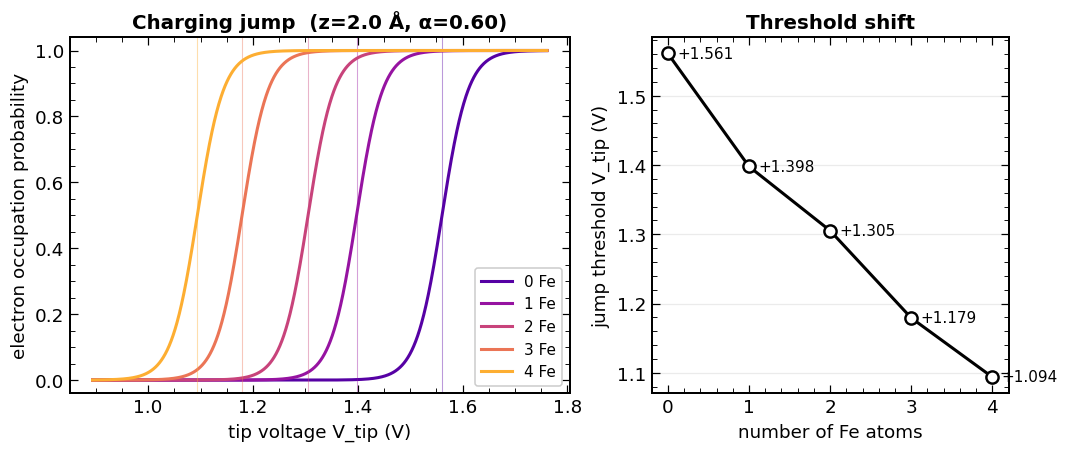

n_Fe   E_LUMO (eV)   E_add (eV)   V_jump (V)
   0       +0.5865     +0.9365     +1.5609
   1       +0.4887     +0.8387     +1.3978
   2       +0.4331     +0.7831     +1.3052
   3       +0.3575     +0.7075     +1.1792
   4       +0.3063     +0.6563     +1.0939


In [10]:
def tip_lever_arm(z_tip, d_ms=3.0):
    return d_ms / (d_ms + np.asarray(z_tip, dtype=float))


def charging_thresholds(max_fe=4, params=None, U_eff=0.35,
                        z_tip=2.0, d_ms=3.0):
    alpha = float(tip_lever_arm(z_tip, d_ms=d_ms))
    lumo = track_reference_orbital('LUMO', max_fe=max_fe, params=params)
    return [{'n_fe':   r['n_fe'],
             'lumo':   r['bias'],
             'E_add':  r['bias'] + U_eff,
             'v_jump': (r['bias'] + U_eff) / alpha,
             'alpha':  alpha} for r in lumo]


def jump_probability(V_tip, v_jump, width=0.025):
    return 1.0 / (1.0 + np.exp(-(np.asarray(V_tip) - v_jump) / width))


def plot_charging_jump(max_fe=4, params=None, U_eff=0.35,
                       z_tip=2.0, d_ms=3.0, width=0.025):
    rows = charging_thresholds(max_fe=max_fe, params=params, U_eff=U_eff,
                               z_tip=z_tip, d_ms=d_ms)
    V_tip = np.linspace(min(r['v_jump'] for r in rows) - 0.20,
                        max(r['v_jump'] for r in rows) + 0.20, 1400)
    colors = plt.cm.plasma(np.linspace(0.15, 0.82, max_fe + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 4.0),
                                   gridspec_kw={'width_ratios': [1.4, 1.0]},
                                   constrained_layout=True)
    for r, color in zip(rows, colors):
        ax1.plot(V_tip, jump_probability(V_tip, r['v_jump'], width=width),
                 color=color, lw=2.0, label=f"{r['n_fe']} Fe")
        ax1.axvline(r['v_jump'], color=color, lw=0.7, alpha=0.4)
    ax1.set_xlabel('tip voltage V_tip (V)')
    ax1.set_ylabel('electron occupation probability')
    ax1.set_title(f'Charging jump  (z={z_tip:.1f} Å, α={rows[0]["alpha"]:.2f})')
    ax1.set_ylim(-0.04, 1.04)
    ax1.legend(loc='lower right')
    origin_style(ax1)

    x = [r['n_fe'] for r in rows]
    y = [r['v_jump'] for r in rows]
    ax2.plot(x, y, 'o-', color='black', lw=2.0, ms=8, mfc='white', mew=1.6)
    for xi, yi in zip(x, y):
        ax2.annotate(f'{yi:+.3f}', xy=(xi, yi), xytext=(6, 0),
                     textcoords='offset points', fontsize=10, va='center')
    ax2.set_xticks(x)
    ax2.set_xlabel('number of Fe atoms')
    ax2.set_ylabel('jump threshold V_tip (V)')
    ax2.set_title('Threshold shift')
    ax2.grid(axis='y', alpha=0.25)
    origin_style(ax2)
    plt.show()

    print('n_Fe   E_LUMO (eV)   E_add (eV)   V_jump (V)')
    for r in rows:
        print(f"{r['n_fe']:>4d}   {r['lumo']:>+11.4f}   "
              f"{r['E_add']:>+9.4f}   {r['v_jump']:>+9.4f}")
    return rows


charging_rows = plot_charging_jump(z_tip=2.0)

## 9. Real-space MO from Slater $2p_z$ LCAO

Slater 2p$_z$ STO at each atom:
$$\chi_{2p_z}(\mathbf r) = N_\zeta\,(z - z_i)\,e^{-\zeta\,|\mathbf r - \mathbf R_i|}.$$

| atom | $\zeta$ (Å$^{-1}$) |
|---|---:|
| C 2p | 2.963 |
| O 2p | 4.208 |

LCAO MO: $\psi^{(n)}(\mathbf r) = \sum_i c_i^{(n)} \chi_{2p_z}(\mathbf r - \mathbf R_i; \zeta_i)$. Plots use a $z$-slice at $z_\mathrm{mol} + 0.6$ Å.

LCAO coefficient matrix C  (n_Fe = 0,  shape (28, 28))
  one row per MO (sorted by energy ascending), columns = atomic sites 0..27

   MO    E(eV)   E-E_F(eV)  |     0       1       2       3       4       5       6       7       8       9      10      11      12      13      14      15      16      17      18      19      20      21      22      23      24      25      26      27
                            |     C       C       C       C       C       C       C       C       C       C       C       C       C       C       C       C       C       C       C       C     Can     Can     Can     Can     Oco     Oco     Oco     Oco
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    0    -9.579    -6.254  | +0.25   +0.32   +0.17   +0.13   +0.16   +0.29   +0.17   +0.13   +0.16   +0.29   +

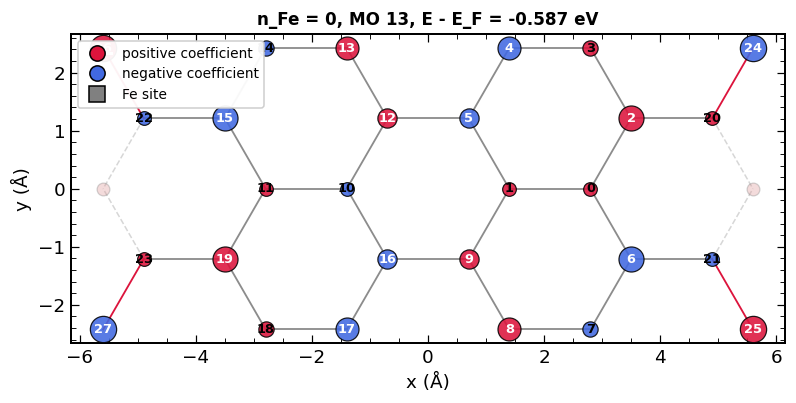

MO 13   E - E_F = -0.5865 eV
normalization check: 1.000000
 idx   atom      coeff        |c|^2
  24   Oco       -0.2883       0.0831
  27   Oco       -0.2883       0.0831
  25   Oco       +0.2883       0.0831
  26   Oco       +0.2883       0.0831
   6   C         -0.2693       0.0725
   2   C         +0.2693       0.0725
  19   C         +0.2693       0.0725
  15   C         -0.2693       0.0725
  17   C         -0.2374       0.0564
  13   C         +0.2374       0.0564
   8   C         +0.2374       0.0564
   4   C         -0.2374       0.0564


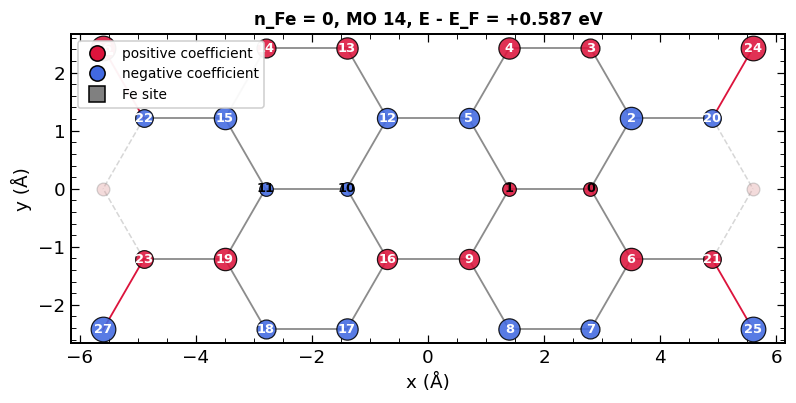

MO 14   E - E_F = +0.5865 eV
normalization check: 1.000000
 idx   atom      coeff        |c|^2
  24   Oco       +0.2633       0.0693
  25   Oco       -0.2633       0.0693
  26   Oco       +0.2633       0.0693
  27   Oco       -0.2633       0.0693
   2   C         -0.2272       0.0516
   6   C         +0.2272       0.0516
  15   C         -0.2272       0.0516
  19   C         +0.2272       0.0516
  13   C         +0.2097       0.0440
  17   C         -0.2097       0.0440
   4   C         +0.2097       0.0440
   8   C         -0.2097       0.0440
tracked HOMO-derived states
n_Fe   state   E-E_F (eV)   shift (eV)   Fe weight
   0      13      -0.5865     +0.0000      0.0000
   1      13      -0.6293     -0.0428      0.0214
   2      13      -0.6735     -0.0870      0.0429
   3      13      -0.7136     -0.1270      0.0600
   4      13      -0.7558     -0.1693      0.0786


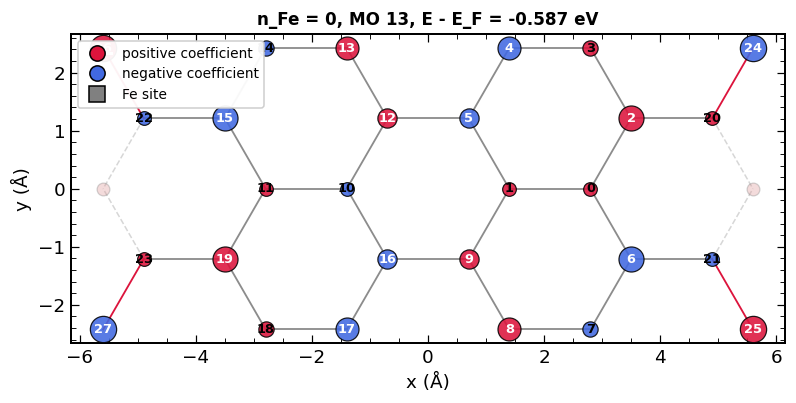

MO 13   E - E_F = -0.5865 eV
normalization check: 1.000000
 idx   atom      coeff        |c|^2
  24   Oco       -0.2883       0.0831
  27   Oco       -0.2883       0.0831
  25   Oco       +0.2883       0.0831
  26   Oco       +0.2883       0.0831
   6   C         -0.2693       0.0725
   2   C         +0.2693       0.0725
  19   C         +0.2693       0.0725
  15   C         -0.2693       0.0725
  17   C         -0.2374       0.0564
  13   C         +0.2374       0.0564
   8   C         +0.2374       0.0564
   4   C         -0.2374       0.0564


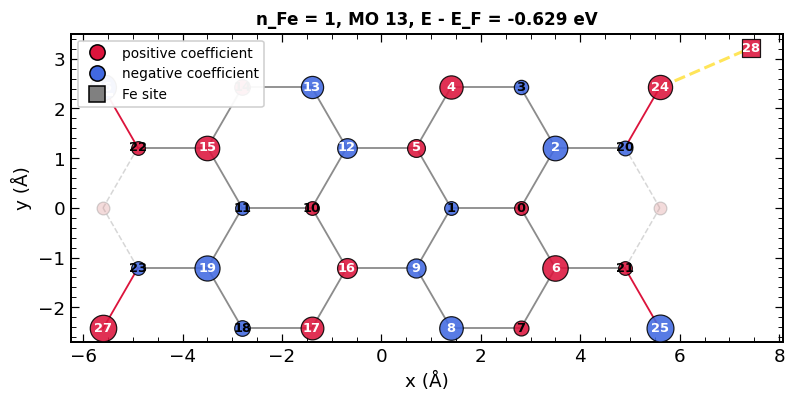

MO 13   E - E_F = -0.6293 eV
normalization check: 1.000000
 idx   atom      coeff        |c|^2
  25   Oco       -0.2972       0.0883
  27   Oco       +0.2912       0.0848
  26   Oco       -0.2814       0.0792
   6   C         +0.2757       0.0760
  19   C         -0.2700       0.0729
   2   C         -0.2624       0.0689
  15   C         +0.2609       0.0681
  24   Oco       +0.2568       0.0659
   8   C         -0.2463       0.0607
   4   C         +0.2417       0.0584
  17   C         +0.2332       0.0544
  13   C         -0.2245       0.0504


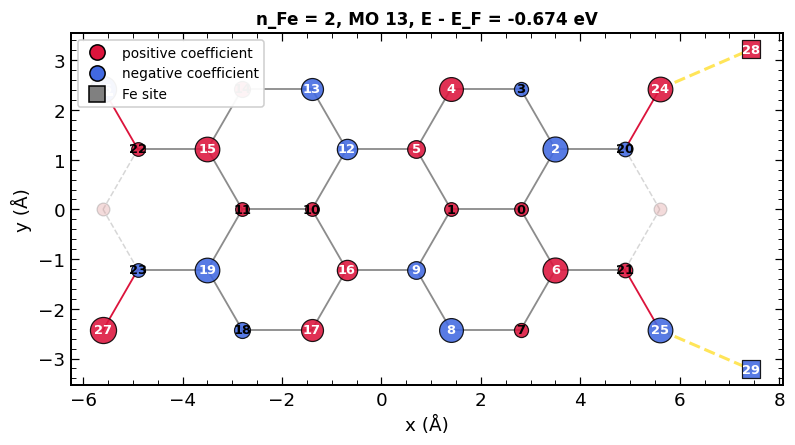

MO 13   E - E_F = -0.6735 eV
normalization check: 1.000000
 idx   atom      coeff        |c|^2
  26   Oco       -0.2856       0.0816
  27   Oco       +0.2856       0.0816
   2   C         -0.2680       0.0718
   6   C         +0.2680       0.0718
  25   Oco       -0.2636       0.0695
  24   Oco       +0.2636       0.0695
  15   C         +0.2628       0.0691
  19   C         -0.2628       0.0691
   4   C         +0.2507       0.0628
   8   C         -0.2507       0.0628
  13   C         -0.2208       0.0488
  17   C         +0.2208       0.0488


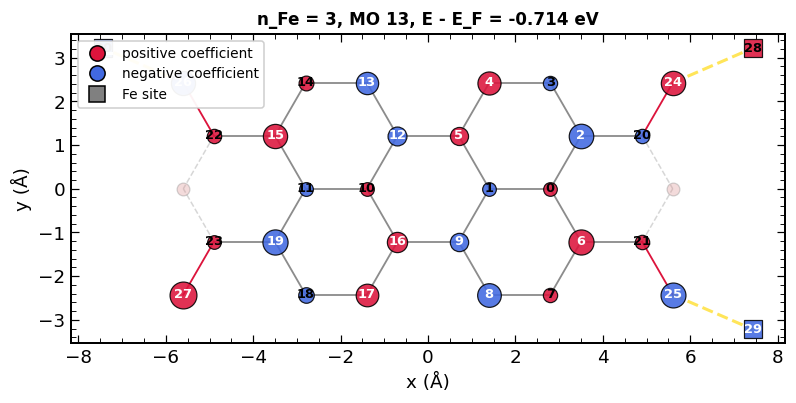

MO 13   E - E_F = -0.7136 eV
normalization check: 1.000000
 idx   atom      coeff        |c|^2
  27   Oco       +0.2971       0.0883
  19   C         -0.2713       0.0736
   6   C         +0.2704       0.0731
  25   Oco       -0.2674       0.0715
   2   C         -0.2615       0.0684
  24   Oco       +0.2586       0.0669
  15   C         +0.2573       0.0662
  26   Oco       -0.2544       0.0647
   8   C         -0.2483       0.0617
   4   C         +0.2396       0.0574
  17   C         +0.2315       0.0536
  13   C         -0.2267       0.0514


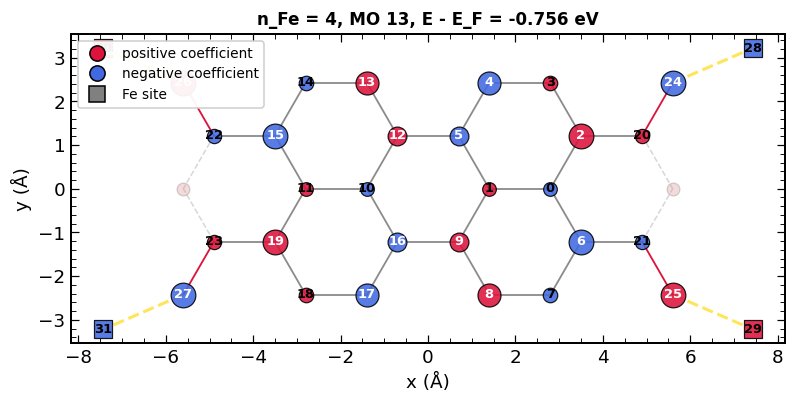

MO 13   E - E_F = -0.7558 eV
normalization check: 1.000000
 idx   atom      coeff        |c|^2
  19   C         +0.2649       0.0702
  15   C         -0.2649       0.0702
   6   C         -0.2649       0.0702
   2   C         +0.2649       0.0702
  27   Oco       -0.2637       0.0695
  26   Oco       +0.2637       0.0695
  25   Oco       +0.2637       0.0695
  24   Oco       -0.2637       0.0695
  13   C         +0.2376       0.0565
  17   C         -0.2376       0.0565
   8   C         +0.2376       0.0565
   4   C         -0.2376       0.0565


In [11]:
def mo_atom_table(sol, mo_index, top_n=12):
    coeff = sol['orbitals'][:, mo_index]
    weight = np.abs(coeff)**2
    bias = float(energy_to_bias(sol['energies'][mo_index], params=sol['params']))

    rows = sorted(
        [{'idx': i, 'label': lab, 'coeff': float(c), 'weight': float(w)}
         for i, (lab, c, w) in enumerate(zip(sol['labels'], coeff, weight))],
        key=lambda r: r['weight'], reverse=True)

    print(f'MO {mo_index}   E - E_F = {bias:+.4f} eV')
    print(f'normalization check: {np.sum(weight):.6f}')
    print(' idx   atom      coeff        |c|^2')
    for r in rows[:top_n]:
        print(f"{r['idx']:>4d}   {r['label']:<4s}   {r['coeff']:>+10.4f}   {r['weight']:>10.4f}")
    return rows


def print_coefficient_matrix(n_fe=0, params=None):
    sol = solve_ptcda_fe(n_fe, params=params)
    C = sol['orbitals']
    E = sol['energies']
    labels = sol['labels']
    n = C.shape[0]

    print(f'LCAO coefficient matrix C  (n_Fe = {n_fe},  shape {C.shape})')
    print(f'  one row per MO (sorted by energy ascending), columns = atomic sites 0..{n - 1}')
    print()

    site_header = '   '.join(f'{lab[:3]:>5s}' for lab in labels)
    idx_header  = '   '.join(f'{i:>5d}'      for i in range(n))
    print(f'   MO    E(eV)   E-E_F(eV)  | ' + idx_header)
    print(f'                            | ' + site_header)
    print('-' * (32 + len(idx_header)))

    fill = combined_filling(n_fe)
    e_f = model_fermi_reference(params)
    for mo in range(n):
        bias = E[mo] - e_f
        tag = ' '
        if mo == fill['homo']:
            tag = 'H'
        elif mo == fill['lumo']:
            tag = 'L'
        row = '   '.join(f'{c:>+5.2f}' for c in C[:, mo])
        print(f'  {mo:>3d}{tag}  {E[mo]:>+7.3f}  {bias:>+8.3f}  | {row}')
    print()
    return C


def plot_mo_2d(n_fe=0, mo_index=HOMO_INDEX, params=None,
               label_atoms=True, scale=2600):
    sol = solve_ptcda_fe(n_fe, params=params)
    coords = sol['coords']
    labels = sol['labels']
    coeff = sol['orbitals'][:, mo_index]
    weight = np.abs(coeff)**2
    bias = float(energy_to_bias(sol['energies'][mo_index], params=sol['params']))

    coords0, labels0, bonds = build_ptcda_geometry(params)

    fig, ax = plt.subplots(figsize=(7.4, 6.6))

    for i, j, _ in bonds:
        col = 'crimson' if 'Oco' in (labels0[i], labels0[j]) else '0.55'
        ax.plot([coords0[i, 0], coords0[j, 0]],
                [coords0[i, 1], coords0[j, 1]],
                color=col, lw=1.2, zorder=1)

    _draw_bridge_o(ax, params=params, alpha=0.35)

    for fe_idx in range(N_PTCDA_SITES, N_PTCDA_SITES + n_fe):
        fe_xy = coords[fe_idx]
        ox_xy = coords[CARBONYL_O[fe_idx - N_PTCDA_SITES]]
        ax.plot([ox_xy[0], fe_xy[0]], [ox_xy[1], fe_xy[1]],
                color='gold', lw=2.0, ls='--', alpha=0.65, zorder=2)

    colors = np.where(coeff >= 0, 'crimson', 'royalblue')
    sizes = 80 + scale * weight

    for i, (xy, lab) in enumerate(zip(coords, labels)):
        marker = 's' if lab == 'Fe' else 'o'
        ax.scatter(xy[0], xy[1], s=sizes[i], c=colors[i], marker=marker,
                   edgecolor='black', linewidth=0.8, alpha=0.88, zorder=3)
        if label_atoms:
            txt_color = 'white' if weight[i] > 0.02 else 'black'
            ax.annotate(str(i), xy=(xy[0], xy[1]), ha='center', va='center',
                        fontsize=8.5, fontweight='bold',
                        color=txt_color, zorder=4)

    ax.set_aspect('equal')
    ax.set_xlabel('x (Å)')
    ax.set_ylabel('y (Å)')
    ax.set_title(f'n_Fe = {n_fe}, MO {mo_index}, E - E_F = {bias:+.3f} eV',
                 fontsize=11)

    from matplotlib.lines import Line2D
    leg = [
        Line2D([0], [0], marker='o', color='w', mfc='crimson', mec='black',
               ms=10, label='positive coefficient'),
        Line2D([0], [0], marker='o', color='w', mfc='royalblue', mec='black',
               ms=10, label='negative coefficient'),
        Line2D([0], [0], marker='s', color='w', mfc='gray', mec='black',
               ms=10, label='Fe site'),
    ]
    ax.legend(handles=leg, loc='upper left', fontsize=9, framealpha=0.95)
    origin_style(ax, minor=False)
    plt.tight_layout()
    plt.show()

    mo_atom_table(sol, mo_index)
    return sol


def plot_tracked_homo_mos(max_fe=4, params=None):
    rows = track_reference_orbital('HOMO', max_fe=max_fe, params=params)

    print('tracked HOMO-derived states')
    print('n_Fe   state   E-E_F (eV)   shift (eV)   Fe weight')
    for r in rows:
        print(f"{r['n_fe']:>4d}   {r['state']:>5d}   "
              f"{r['bias']:>+10.4f}   {r['shift_V']:>+9.4f}   "
              f"{r['fe_weight']:>9.4f}")

    for r in rows:
        plot_mo_2d(n_fe=r['n_fe'], mo_index=r['state'], params=params)
    return rows


for n in range(5):
    print_coefficient_matrix(n_fe=n)

plot_mo_2d(n_fe=0, mo_index=HOMO_INDEX)
plot_mo_2d(n_fe=0, mo_index=LUMO_INDEX)

tracked_homo_rows = plot_tracked_homo_mos()

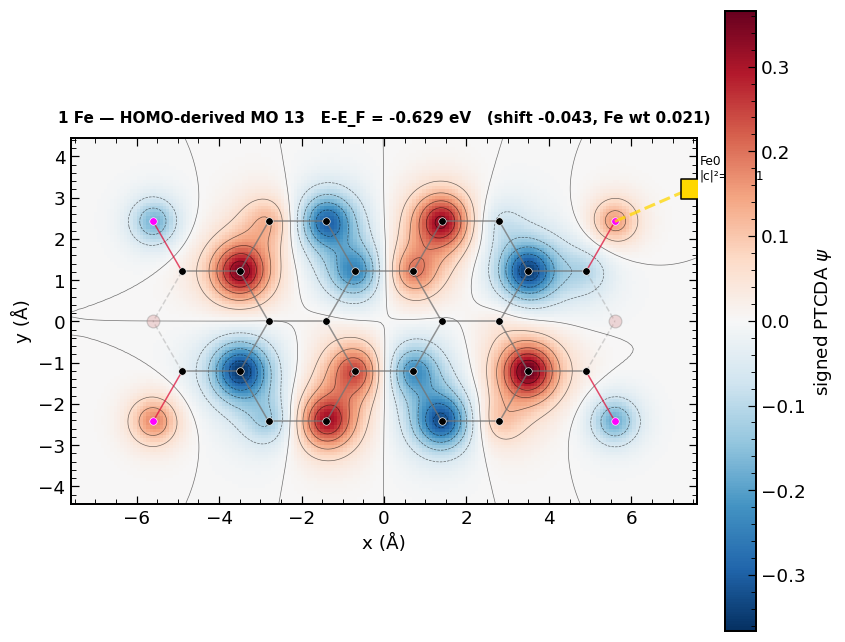

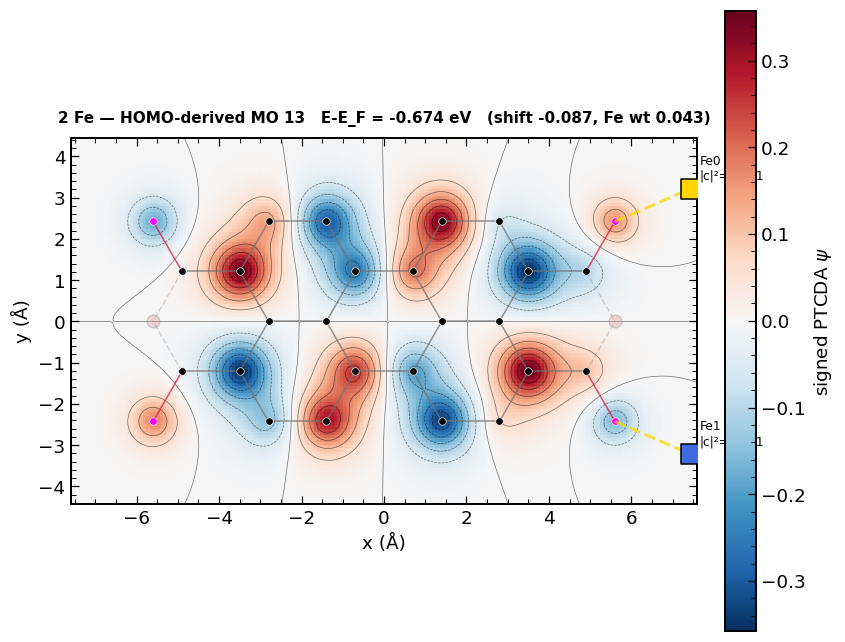

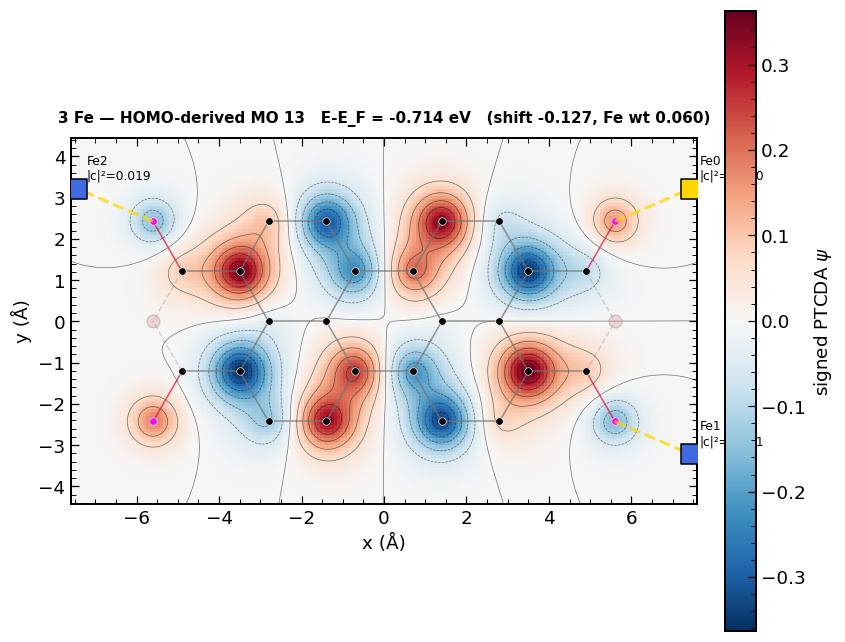

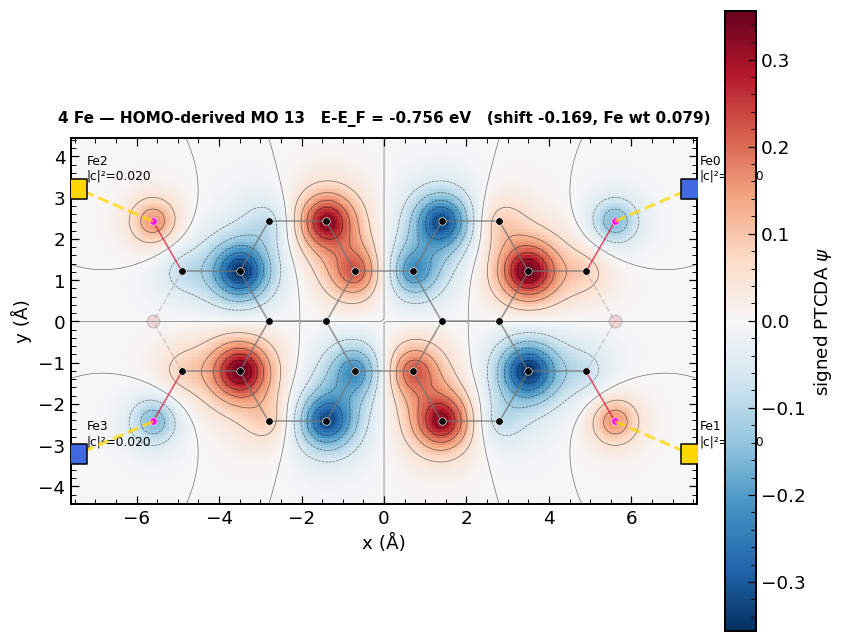

In [12]:
A0_ANG         = 0.529177
Z_MOL_ABOVE_AG = 2.86

ZETA_C_PZ = 1.5679 / A0_ANG
ZETA_O_PZ = 2.2266 / A0_ANG
ZETA_BY_LABEL = {'C': ZETA_C_PZ, 'Can': ZETA_C_PZ, 'Oco': ZETA_O_PZ}


def slater_2pz_slice(X, Y, z_slice, R0, zeta):
    dx, dy, dz = X - R0[0], Y - R0[1], z_slice - R0[2]
    r = np.sqrt(dx*dx + dy*dy + dz*dz)
    return dz * np.exp(-zeta * r)


def ptcda_psi_slice_from_bound_mo(sol, mo_index, z_above_mol=0.6, dxy=0.08,
                                  pad_xy=2.0):
    coords_2d = sol['coords'][:N_PTCDA_SITES]
    labels = sol['labels'][:N_PTCDA_SITES]
    coords_3d = np.column_stack([coords_2d, np.full(N_PTCDA_SITES, Z_MOL_ABOVE_AG)])
    coeff = sol['orbitals'][:N_PTCDA_SITES, mo_index]

    x_min, x_max = coords_3d[:, 0].min() - pad_xy, coords_3d[:, 0].max() + pad_xy
    y_min, y_max = coords_3d[:, 1].min() - pad_xy, coords_3d[:, 1].max() + pad_xy
    x = np.arange(x_min, x_max + dxy, dxy)
    y = np.arange(y_min, y_max + dxy, dxy)
    X, Y = np.meshgrid(x, y, indexing='ij')

    z_slice = Z_MOL_ABOVE_AG + z_above_mol
    psi = np.zeros_like(X)
    for c, R, lab in zip(coeff, coords_3d, labels):
        psi += c * slater_2pz_slice(X, Y, z_slice, R, ZETA_BY_LABEL[lab])

    psi /= np.sqrt(np.sum(psi * psi) * dxy * dxy) + 1e-30
    return X, Y, psi


def plot_bound_homo_derived_mo(n_fe=1, params=None, z_above_mol=0.6,
                               dxy=0.08, n_levels=13):
    row = track_reference_orbital('HOMO', max_fe=n_fe, params=params)[n_fe]
    sol = solve_ptcda_fe(n_fe, params=params)
    mo_index = row['state']

    X, Y, psi = ptcda_psi_slice_from_bound_mo(
        sol, mo_index, z_above_mol=z_above_mol, dxy=dxy)

    coords_2d, labels_2d, bonds = build_ptcda_geometry(params)
    coeff = sol['orbitals'][:, mo_index]

    vmax = np.max(np.abs(psi))
    levels = np.linspace(-vmax, vmax, n_levels)

    fig, ax = plt.subplots(figsize=(7.8, 6.0))
    im = ax.imshow(psi.T, origin='lower',
                   extent=[X.min(), X.max(), Y.min(), Y.max()],
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
    ax.contour(X, Y, psi, levels=levels, colors='black',
               linewidths=0.45, alpha=0.55)

    for i, j, _ in bonds:
        col = 'crimson' if 'Oco' in (labels_2d[i], labels_2d[j]) else '0.45'
        ax.plot([coords_2d[i, 0], coords_2d[j, 0]],
                [coords_2d[i, 1], coords_2d[j, 1]],
                color=col, lw=1.0, alpha=0.75, zorder=3)

    for R, lab in zip(coords_2d, labels_2d):
        ax.scatter(R[0], R[1],
                   c='black' if lab in ('C', 'Can') else 'magenta',
                   s=24, edgecolor='white', linewidth=0.4, zorder=4)

    for k in range(n_fe):
        fe_idx = N_PTCDA_SITES + k
        fe_xy  = sol['coords'][fe_idx]
        ox_xy  = sol['coords'][CARBONYL_O[k]]
        fe_c   = coeff[fe_idx]
        fe_w   = abs(fe_c)**2
        ax.plot([ox_xy[0], fe_xy[0]], [ox_xy[1], fe_xy[1]],
                color='gold', lw=2.0, ls='--', alpha=0.75, zorder=5)
        ax.scatter(fe_xy[0], fe_xy[1],
                   s=120 + 2800 * fe_w, marker='s',
                   c='gold' if fe_c >= 0 else 'royalblue',
                   edgecolor='black', linewidth=1.0, zorder=6)
        ax.annotate(f'Fe{k}\n|c|²={fe_w:.3f}',
                    xy=(fe_xy[0], fe_xy[1]), xytext=(6, 6),
                    textcoords='offset points', fontsize=8)

    _draw_bridge_o(ax, params=sol['params'], alpha=0.35)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label=r'signed PTCDA $\psi$')
    ax.set_xlabel('x (Å)')
    ax.set_ylabel('y (Å)')
    ax.set_title(
        f"{n_fe} Fe — HOMO-derived MO {mo_index}   "
        f"E-E_F = {row['bias']:+.3f} eV   "
        f"(shift {row['shift_V']:+.3f}, Fe wt {row['fe_weight']:.3f})",
        fontsize=10, pad=10)
    origin_style(ax)
    plt.tight_layout()
    plt.show()
    return sol, row, psi


# Fe 결합 후 HOMO-derived MO
for n in (1, 2, 3, 4):
    plot_bound_homo_derived_mo(n_fe=n)